<a href="https://colab.research.google.com/github/NikhilGeorge01/DeepLearningPractice/blob/main/optimmdethods(week4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [ ]:
tf.config.run_functions_eagerly(True)
tf.random.set_seed(42)
np.random.seed(42)

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

def build_model():
    return keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

# Define optimizer configurations, but instantiate them inside the loop
optimizer_configs = {
    "BGD": {"class": keras.optimizers.SGD, "kwargs": {"learning_rate": 0.1}},
    "SGD": {"class": keras.optimizers.SGD, "kwargs": {"learning_rate": 0.1}},
    "MiniBatchGD": {"class": keras.optimizers.SGD, "kwargs": {"learning_rate": 0.1}},
    "SGD_Momentum": {"class": keras.optimizers.SGD, "kwargs": {"learning_rate": 0.1, "momentum": 0.9}},
    "Nesterov": {"class": keras.optimizers.SGD, "kwargs": {"learning_rate": 0.1, "momentum": 0.9, "nesterov": True}},
    "Adagrad": {"class": keras.optimizers.Adagrad, "kwargs": {"learning_rate": 0.1}},
    "RMSProp": {"class": keras.optimizers.RMSprop, "kwargs": {"learning_rate": 0.01}},
    "Adadelta": {"class": keras.optimizers.Adadelta, "kwargs": {}},
    "Adam": {"class": keras.optimizers.Adam, "kwargs": {"learning_rate": 0.01}}
}



In [ ]:
xor_histories = {}

for name, config in optimizer_configs.items():
    model = build_model()
    opt = config["class"](**config["kwargs"])
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    if name == "BGD":
        history = model.fit(X_xor, y_xor, epochs=300, batch_size=4, verbose=0)
    elif name == "SGD":
        history = model.fit(X_xor, y_xor, epochs=300, batch_size=1, verbose=0)
    else:
        history = model.fit(X_xor, y_xor, epochs=300, batch_size=2, verbose=0)
    xor_histories[name] = history.history['loss']



/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


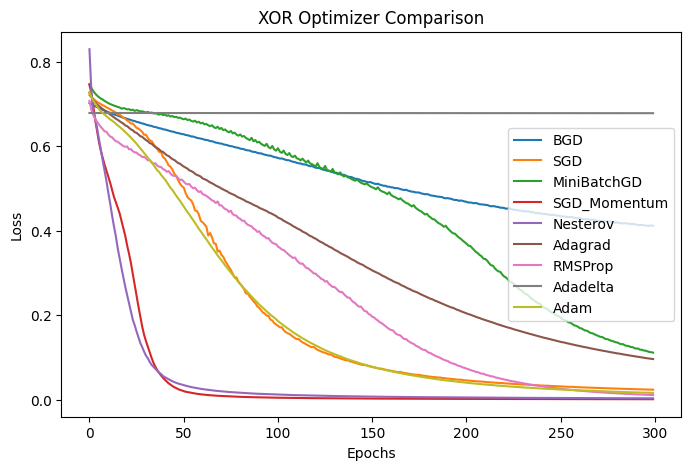

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


BGD Accuracy: 0.9866666793823242
SGD Accuracy: 0.9866666793823242
MiniBatchGD Accuracy: 0.9733333587646484
SGD_Momentum Accuracy: 0.9866666793823242
Nesterov Accuracy: 0.9866666793823242
Adagrad Accuracy: 0.9866666793823242
RMSProp Accuracy: 0.9800000190734863
Adadelta Accuracy: 0.5133333206176758
Adam Accuracy: 0.9933333396911621


In [ ]:
plt.figure(figsize=(8,5))
for name in xor_histories:
    plt.plot(xor_histories[name], label=name)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("XOR Optimizer Comparison")
plt.show()

X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

for name, config in optimizer_configs.items():
    model = build_model()
    opt = config["class"](**config["kwargs"])
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(name, "Accuracy:", acc)